# Target variance — between-player vs within-player (Y)

*Read-only informative artifact. Decomposes the season-pooled spread of
`total_points` into a between-player component and a within-player component,
so a human can decide what matters. No gate decisions, no PROCEED/STOP
verdict.*

## Questions a manager asks of the target's variance

- **How much of a player's scoring is who they are vs which week it is?** If
  most of the spread in `total_points` is between players, "own the right
  players" is the dominant lever. If most of it is within a player week to
  week, timing and captaincy matter more.
- **Does this split differ by position?**

This is the player-grain sibling of `structure/target.ipynb`'s positional
spread (section a): same "how wide is the typical band" question, decomposed
by *who* contributes to that width rather than just *how wide* it is.

Everything below is **season-pooled** over the study range. *Why* within-player
variance exists (form, fixtures) is deferred to the `temporal/` and `fixture/`
layers. *Which* players sit in the between-player tail is a player-level question outside the scope of this notebook.

## Setup

Load the mart, restrict to the **whole season** (GW 1 to the latest completed
GW) and to the **participation** population (`minutes > 0`), and build position
cohorts — the same population as `structure/target.ipynb`.
See that notebook for the rationale behind the
whole-season range and the participation (not performance) filter.

This notebook additionally groups by `player_id`, since the decomposition below
splits variance by player rather than by position alone.

**Double-gameweek (DGW) honesty note.** A DGW player-gameweek sums two
fixtures into one `total_points` row, inflating that row's value — which in
turn inflates both that player's own mean and their within-player spread
slightly. The next section sizes the prevalence; this notebook does not correct
for it (per-fixture treatment is deferred to the `fixture/` layer, as in
`target.ipynb`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from research.kernels.descriptive.variance_components import (
    decompose_variance,
    DEFAULT_MIN_APPEARANCES,
)

try:
    _result = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _result = load_mart()

STUDY_GW_MIN = 1
STUDY_GW_MAX = _result.data_cutoff_gw

mart = _result.mart
df = mart[mart["gw"].between(STUDY_GW_MIN, STUDY_GW_MAX)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()

POSITIONS = ["GK", "DEF", "MID", "FWD"]
cohorts = {pos: df[df.position == pos] for pos in POSITIONS}

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.3f}".format)

print(f"Study range: GW {STUDY_GW_MIN} - GW {STUDY_GW_MAX} (whole season, from mart data_cutoff_gw)")
print(f"Population: minutes > 0 (participation, not a performance gate), n = {len(df):,} player-gameweeks")
for pos in POSITIONS:
    print(f"  {pos}: {len(cohorts[pos]):>6,}")

Study range: GW 1 - GW 38 (whole season, from mart data_cutoff_gw)
Population: minutes > 0 (participation, not a performance gate), n = 11,361 player-gameweeks
  GK:    757
  DEF:  3,904
  MID:  5,288
  FWD:  1,412


## DGW prevalence — magnitude of the fixture-doubling confound

*How much of the featured population is double-gameweek?*

**What we measure** — share of featured player-gameweeks (`minutes > 0`) that
are double-gameweeks (`is_dgw == True`), by position.

**What it means** — a DGW row's `total_points` is roughly double a single
fixture's worth, which inflates that player's own mean and within-player spread
for the gameweek it occurs. This sizes how much of the per-player data feeding
the decomposition below is affected.

**What it doesn't mean** — description of prevalence only; no normalisation or
exclusion. Per-fixture treatment is deferred to the `fixture/` layer.

In [2]:
# DGW prevalence by position (descriptive only -- no normalisation, no exclusion).
_dgw = df.groupby("position")["is_dgw"].agg(n="count", dgw_rows="sum").reset_index()
_all = pd.DataFrame([{"position": "ALL", "n": len(df), "dgw_rows": int(df["is_dgw"].sum())}])
dgw_prevalence = (
    pd.concat([_dgw, _all], ignore_index=True)
    .assign(**{"dgw_%": lambda d: (d["dgw_rows"] / d["n"] * 100).round(2)})
)
display(dgw_prevalence)

,position,n,dgw_rows,dgw_%
0,DEF,3904,59,1.510
1,FWD,1412,22,1.560
2,GK,757,10,1.320
3,MID,5288,80,1.510
4,ALL,11361,171,1.510


## (a) Variance decomposition — between-player vs within-player

**What we measure** — for each position, `decompose_variance` splits the total
sum-of-squares of `total_points` into a between-player component
(`SS_between` — how far each player's own mean sits from the position's grand
mean) and a within-player component (`SS_within` — how far each appearance
sits from that player's own mean), reported as `pct_between` and `pct_within`
(they sum to 100). Players with fewer than `min_appearances` (default 10)
player-gameweeks are excluded — their own mean is too noisy to anchor a
within-player figure.

**What it means** — a high `pct_between` means most of a position's spread is
explained by *who* the player is: some players are persistently better, and the
spread seen in `target.ipynb` section (a) is mostly "different players, same
week." A high `pct_within` means most of the spread is week-to-week: any given
player's output swings a lot, and the spread is mostly "same player, different
week."

**What it doesn't mean** — this is a single aggregate split per position; it
doesn't say *which* players sit in the between-player tail (a player-level question outside the scope of this notebook), or *why* within-player variance exists (form,
fixtures — deferred to `temporal/`, `fixture/`). Excluding players below
`min_appearances` narrows the population to regular-rotation players.

**Guiding question** — *Is a position's spread driven by who's playing or which
week it is?*

In [3]:
rows = []
for pos in POSITIONS:
    result = decompose_variance(cohorts[pos], value_col="total_points", group_col="player_id")
    result["position"] = pos
    rows.append(result)
variance_decomp = pd.DataFrame(rows).set_index("position")
print(f"min_appearances = {DEFAULT_MIN_APPEARANCES} player-gameweeks\n")
display(variance_decomp[["n_players", "n_obs", "grand_mean", "pct_between", "pct_within"]].round(2))

min_appearances = 10 player-gameweeks



,n_players,n_obs,grand_mean,pct_between,pct_within
position,,,,,
GK,25,704,3.450,3.630,96.370
DEF,146,3733,3.150,9.230,90.770
MID,191,5086,3.010,13.600,86.400
FWD,52,1355,3.050,14.120,85.880


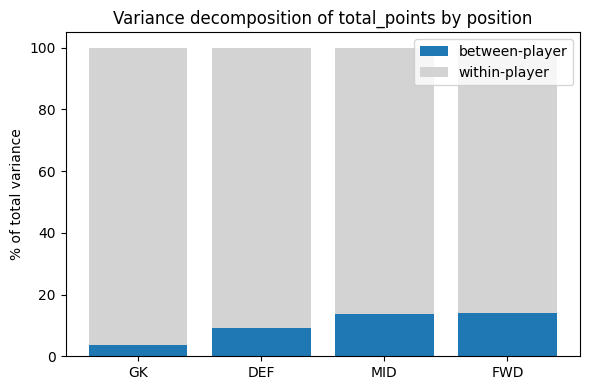

In [4]:
# Stacked bar makes the between/within split directly comparable across positions.
fig, ax = plt.subplots(figsize=(6, 4))
positions = variance_decomp.index.tolist()
between = variance_decomp["pct_between"].values
within = variance_decomp["pct_within"].values
ax.bar(positions, between, label="between-player", color="#1f77b4")
ax.bar(positions, within, bottom=between, label="within-player", color="#d3d3d3")
ax.set_ylabel("% of total variance")
ax.set_title("Variance decomposition of total_points by position")
ax.legend()
plt.tight_layout()
plt.show()

## What the target's variance looks like

Plain-language summary (not a verdict):

| position | pct_between | pct_within |
|---|---|---|
| GK  | ~4%  | ~96% |
| DEF | ~9%  | ~91% |
| MID | ~14% | ~86% |
| FWD | ~14% | ~86% |

- **Within-player variance dominates at every position** — roughly 85-96% of
  the spread in `total_points` is week-to-week, not who-the-player-is. Most of
  what `target.ipynb` describes as "spread" is the same player producing very
  different scores from one gameweek to the next.
- **GK has the most within-player variance (~96%) and the least between-player
  variance (~4%)** — GK output is the most "any week could be any score" of any
  position.
- **MID and FWD have the largest between-player share (~14%)** — still a small
  minority of total variance, but roughly 3x GK's. A modest part of the spread
  in `target.ipynb` is "some MID/FWD are persistently better than others," more
  so than at GK/DEF.
- **This is one aggregate number per position** — it doesn't say *which*
  players make up the between-player tail (a player-level question outside the scope of this notebook) or *why* within-player variance exists (form,
  fixtures — deferred to `temporal/`, `fixture/`).

All figures are **whole-season**, season-pooled, over the **participation**
population (`minutes > 0`), excluding players with fewer than `min_appearances`
(default 10) player-gameweeks.